## Imports

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 110,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

## Config Constants

In [2]:
DATA_DIR = Path("../data")

In [3]:
tables = {
    "adl_responses": os.path.join(DATA_DIR, "adl_responses.parquet"),
    "care_plans": os.path.join(DATA_DIR, "care_plans.parquet"),
    "diagnoses": os.path.join(DATA_DIR, "diagnoses.parquet"),
    "document_tags": os.path.join(DATA_DIR, "document_tags.parquet"),
    "factors": os.path.join(DATA_DIR, "factors.parquet"),
    "gg_responses": os.path.join(DATA_DIR, "gg_responses.parquet"),
    "hospital_admissions": os.path.join(DATA_DIR, "hospital_admissions.parquet"),
    "hospital_transfers": os.path.join(DATA_DIR, "hospital_transfers.parquet"),
    "incidents": os.path.join(DATA_DIR, "incidents.parquet"),
    "injuries": os.path.join(DATA_DIR, "injuries.parquet"),
    "lab_reports": os.path.join(DATA_DIR, "lab_reports.parquet"),
    "medications": os.path.join(DATA_DIR, "medications.parquet"),
    "needs": os.path.join(DATA_DIR, "needs.parquet"),
    "physician_orders": os.path.join(DATA_DIR, "physician_orders.parquet"),
    "residents": os.path.join(DATA_DIR, "residents.parquet"),
    "therapy_tracks": os.path.join(DATA_DIR, "therapy_tracks.parquet"),
    "vitals": os.path.join(DATA_DIR, "vitals.parquet"),
}

## Tables Input

In [4]:
dfs = {name: pd.read_parquet(path) for name, path in tables.items()}

incidents = dfs["incidents"]
residents = dfs["residents"]
injuries = dfs["injuries"]
factors = dfs["factors"]
adl = dfs["adl_responses"]
gg = dfs["gg_responses"]
diagnoses = dfs["diagnoses"]
medications = dfs["medications"]
vitals = dfs["vitals"]
lab_reports = dfs["lab_reports"]
care_plans = dfs["care_plans"]
needs = dfs["needs"]
physician_orders = dfs["physician_orders"]
hospital_admissions = dfs["hospital_admissions"]
hospital_transfers = dfs["hospital_transfers"]
therapy_tracks = dfs["therapy_tracks"]
document_tags = dfs["document_tags"]

inc_valid = incidents[~incidents["strikeout"]].copy()
incident_residents = set(inc_valid["resident_id"])

print(f"Loaded {len(dfs)} tables · {len(inc_valid)} valid incidents across {len(incident_residents)} residents")

Loaded 17 tables · 3382 valid incidents across 978 residents


## Charts

### Chart 1 — Incident Type Distribution

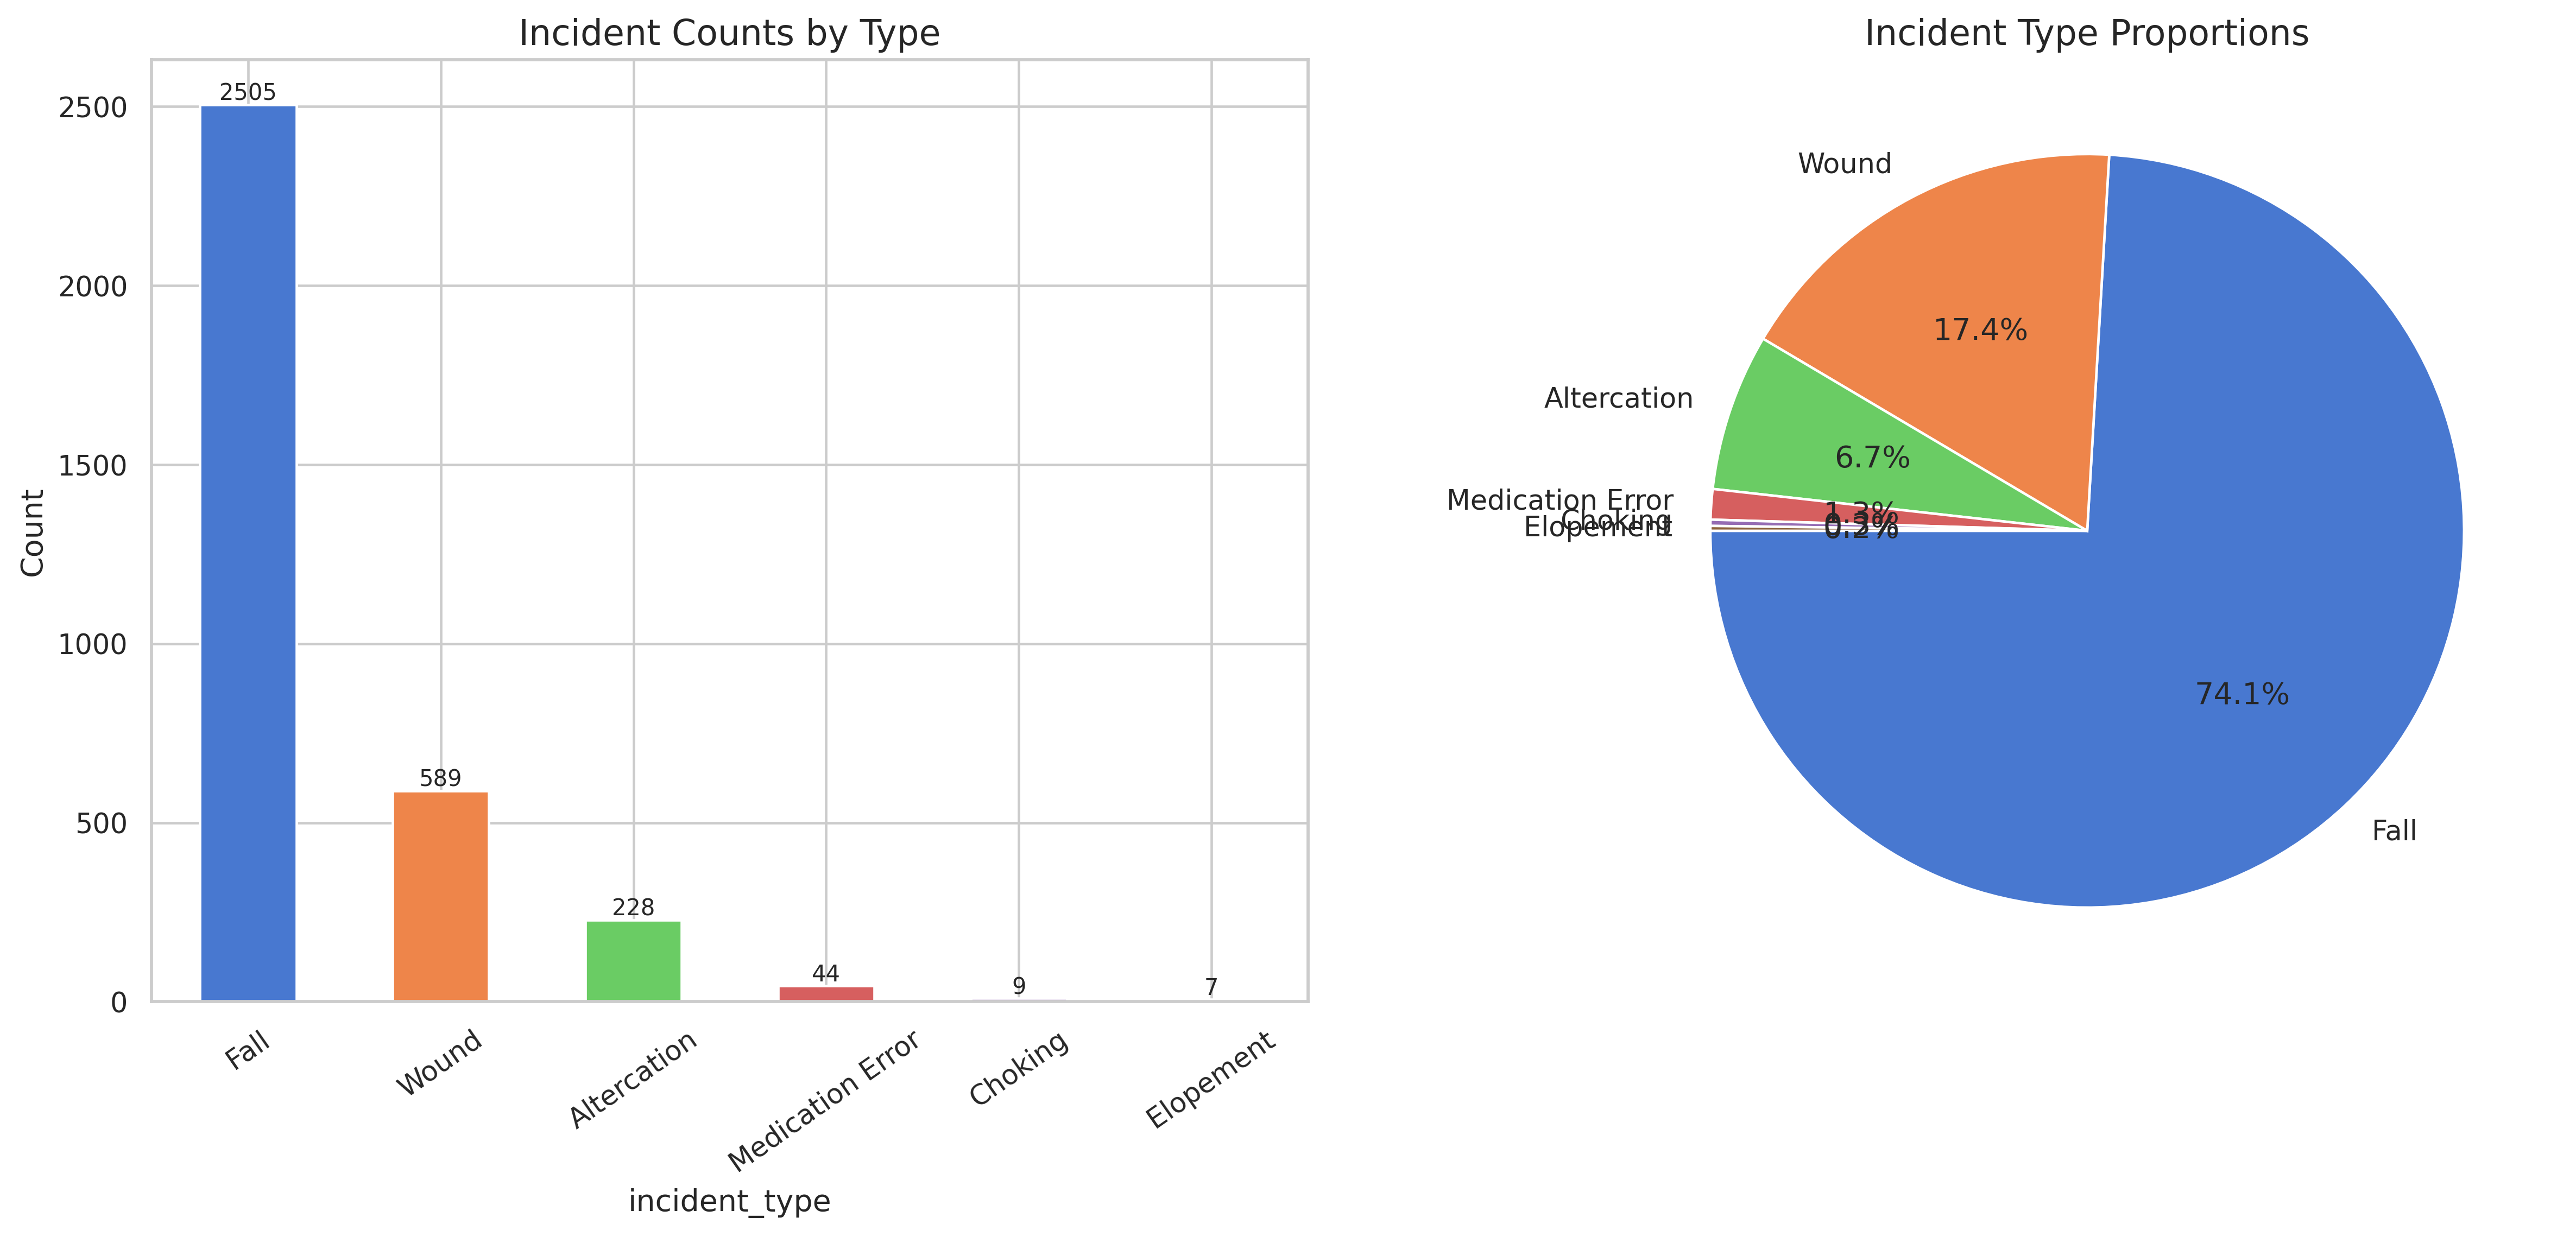

In [5]:
## Chart 1 — Incident Type Distribution

type_counts = inc_valid["incident_type"].value_counts()
colors = sns.color_palette("muted", len(type_counts))

fig, axes = plt.subplots(1, 2, figsize=(15, 7), dpi=333)

type_counts.plot.bar(ax=axes[0], color=colors, edgecolor="white")
axes[0].set_title("Incident Counts by Type")
axes[0].set_ylabel("Count")
axes[0].bar_label(axes[0].containers[0], fontsize=9)
axes[0].tick_params(axis="x", rotation=35)

type_counts.plot.pie(ax=axes[1], autopct="%1.1f%%", startangle=180, colors=colors)
axes[1].set_ylabel("")
axes[1].set_title("Incident Type Proportions")

plt.tight_layout()
plt.show()

In [6]:
perc_df = (type_counts / type_counts.sum() * 100).round(2).reset_index()
perc_df.columns = ["Incident Type", "Actual Proportion (%)"]
# Add expected percentages from README

perc_df["Expected Proportion (%)"] = [13.0, 7.0, 2.0, 10.0, np.nan, 5.0]
display(perc_df)

,Incident Type,Actual Proportion (%),Expected Proportion (%)
0,Fall,74.07,13.0
1,Wound,17.42,7.0
2,Altercation,6.74,2.0
3,Medication Error,1.30,10.0
4,Choking,0.27,NaN
5,Elopement,0.21,5.0


### Chart 2 — Incidents Over Time (Monthly, Stacked by Type)

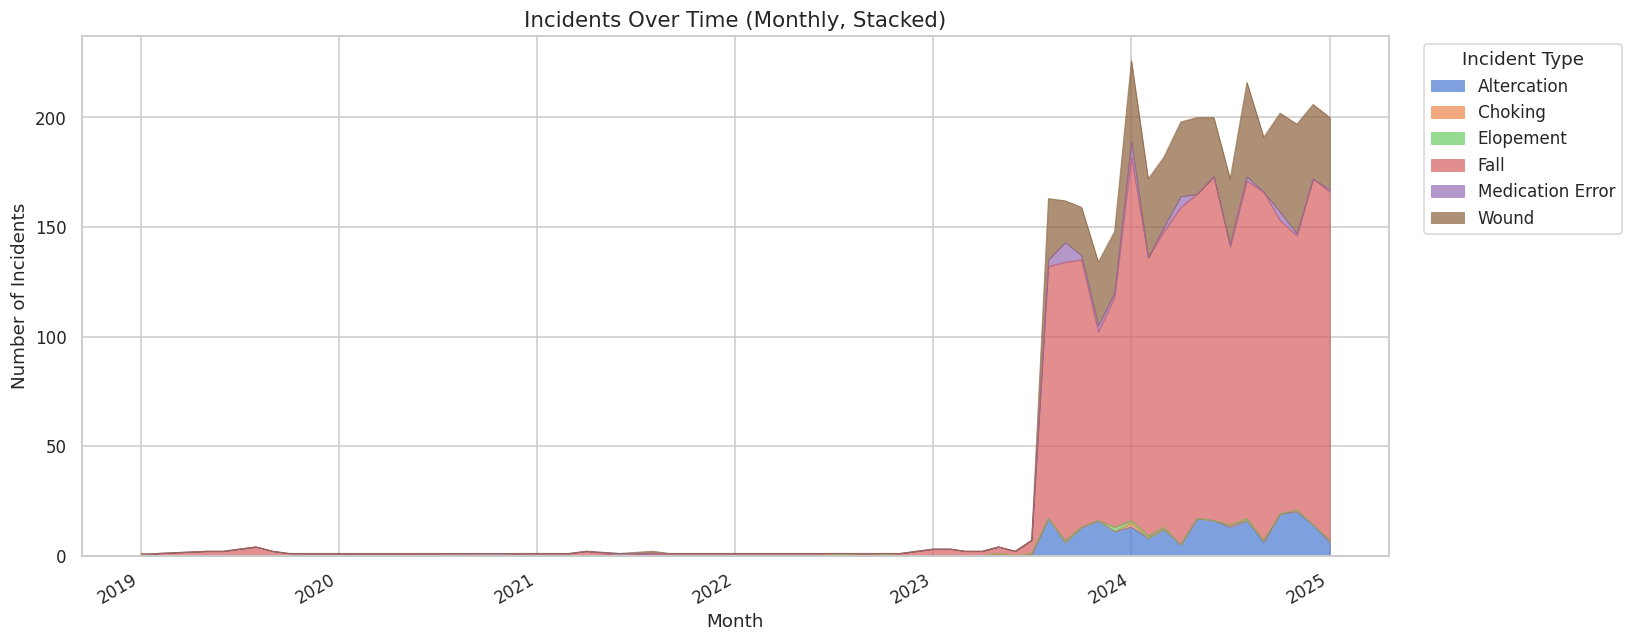

In [7]:
## Chart 2 — Incidents Over Time (Monthly, Stacked by Type)

inc_ts = inc_valid.copy()
inc_ts["month"] = inc_ts["occurred_at"].dt.to_period("M")
monthly = inc_ts.groupby(["month", "incident_type"]).size().unstack(fill_value=0)
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(15, 6))
monthly.plot.area(ax=ax, alpha=0.7, stacked=True, linewidth=0.5)
ax.set_title("Incidents Over Time (Monthly, Stacked)")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Incidents")
ax.legend(title="Incident Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Charts 3 & 4 — Incidents by Age and Time Since Admission

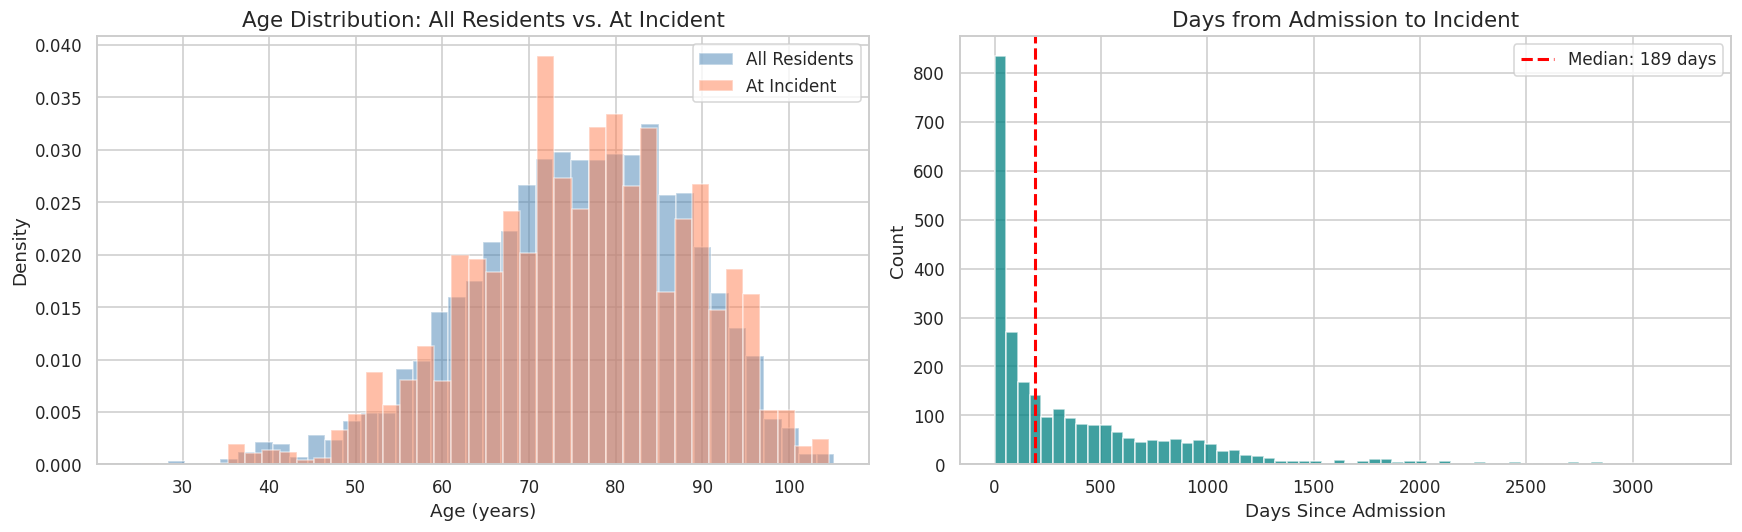

In [8]:
## Charts 3 & 4 — Incidents by Age and Time Since Admission

inc_res = inc_valid.merge(
    residents[["resident_id", "date_of_birth"]], on="resident_id", how="left")
inc_res["age_at_incident"] = (
    (inc_res["occurred_at"] - inc_res["date_of_birth"]).dt.days / 365.25)

ref_date = inc_valid["occurred_at"].max()
all_res = residents.copy()
all_res["age"] = (ref_date - all_res["date_of_birth"]).dt.days / 365.25

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(all_res["age"].dropna(), bins=40, density=True, alpha=0.5,
             label="All Residents", color="steelblue", edgecolor="white")
axes[0].hist(inc_res["age_at_incident"].dropna(), bins=40, density=True, alpha=0.5,
             label="At Incident", color="coral", edgecolor="white")
axes[0].set_title("Age Distribution: All Residents vs. At Incident")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Density")
axes[0].legend()

inc_adm = inc_valid.merge(
    residents[["resident_id", "admission_date"]], on="resident_id", how="left")
inc_adm["days_since_adm"] = (
    (inc_adm["occurred_at"] - inc_adm["admission_date"]).dt.days)
days_col = inc_adm["days_since_adm"].dropna()
days_col = days_col[(days_col >= 0) & (days_col <= days_col.quantile(0.99))]

axes[1].hist(days_col, bins=60, color="teal", alpha=0.75, edgecolor="white")
med = days_col.median()
axes[1].axvline(med, color="red", ls="--", lw=2, label=f"Median: {med:.0f} days")
axes[1].set_title("Days from Admission to Incident")
axes[1].set_xlabel("Days Since Admission")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

### Chart 5 — Incident Location Breakdown

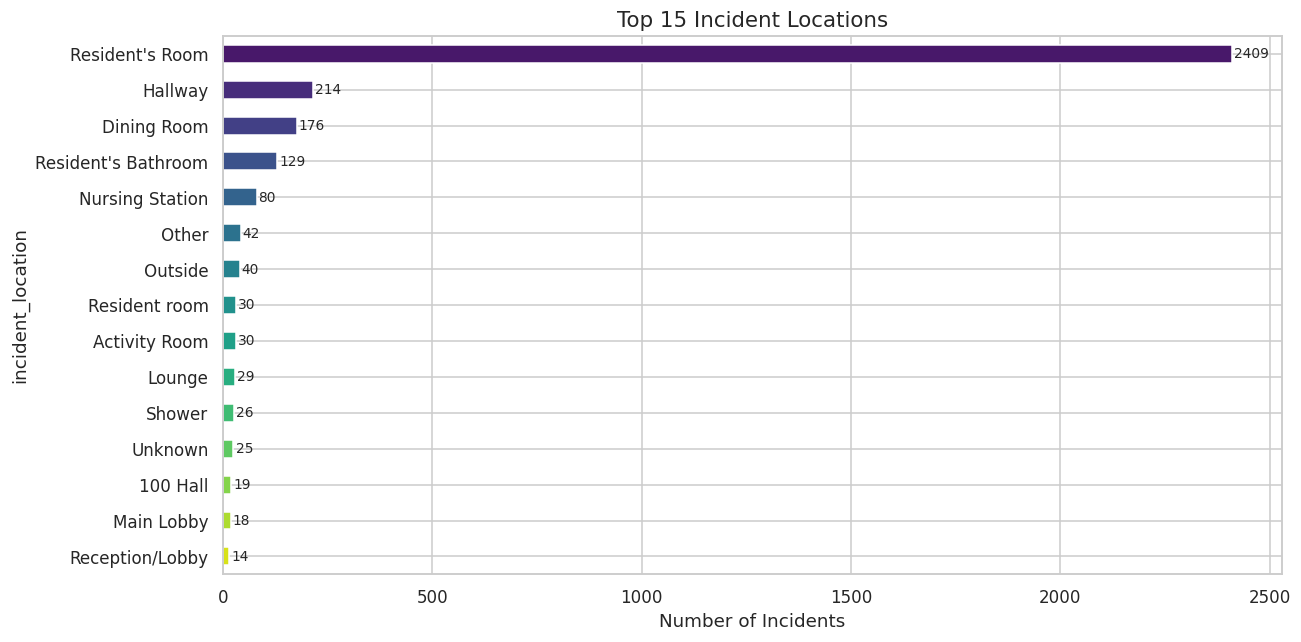

In [9]:
## Chart 5 — Incident Location Breakdown

loc_counts = inc_valid["incident_location"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette("viridis", len(loc_counts))
loc_counts.plot.barh(ax=ax, color=colors, edgecolor="white")
ax.set_title("Top 15 Incident Locations")
ax.set_xlabel("Number of Incidents")
ax.invert_yaxis()
for i, v in enumerate(loc_counts):
    ax.text(v + 5, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()

### Chart 6 — Average ADL Score in Weeks Before Incident

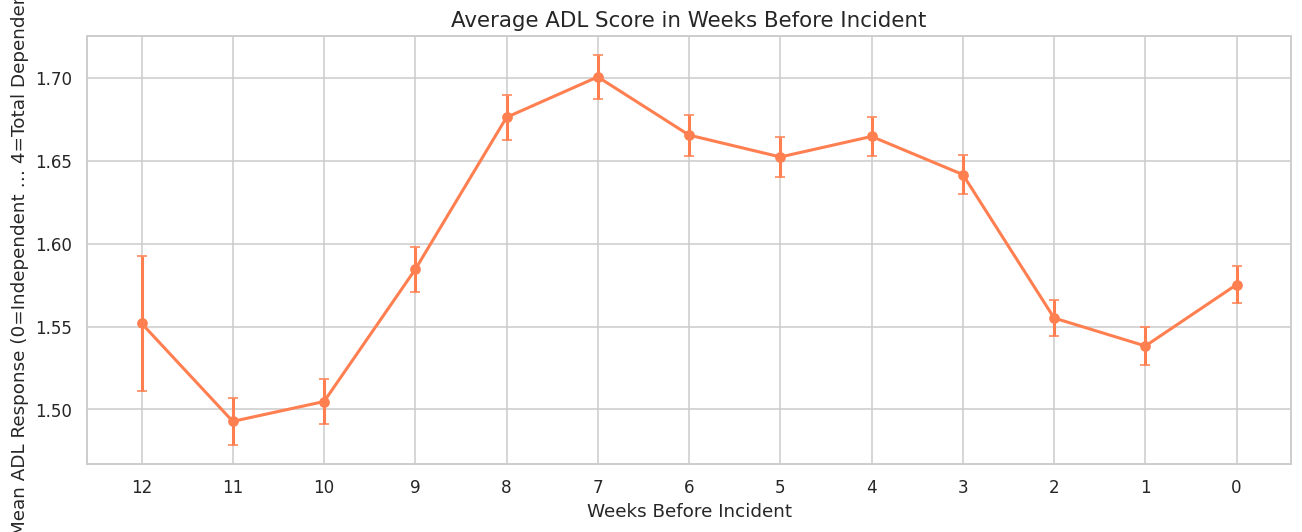

In [10]:
## Chart 6 — Average ADL Score in Weeks Before Incident

adl_numeric = adl[adl["response"].str.match(r"^\d+$", na=False)].copy()
adl_numeric["response_val"] = adl_numeric["response"].astype(int)

inc_dates = inc_valid[["resident_id", "occurred_at"]].drop_duplicates()
adl_inc = adl_numeric.merge(inc_dates, on="resident_id")
adl_inc["days_before"] = (adl_inc["occurred_at"] - adl_inc["assessment_date"]).dt.days
adl_inc = adl_inc[(adl_inc["days_before"] >= 0) & (adl_inc["days_before"] <= 84)]
adl_inc["week_before"] = adl_inc["days_before"] // 7

traj = adl_inc.groupby("week_before")["response_val"].agg(["mean", "sem"])

fig, ax = plt.subplots(figsize=(12, 5))
ax.errorbar(traj.index, traj["mean"], yerr=traj["sem"],
            marker="o", capsize=3, lw=2, color="coral")
ax.set_title("Average ADL Score in Weeks Before Incident")
ax.set_xlabel("Weeks Before Incident")
ax.set_ylabel("Mean ADL Response (0=Independent … 4=Total Dependence)")
ax.invert_xaxis()
ax.set_xticks(range(0, 13))
plt.tight_layout()
plt.show()

### Chart 7 — Vital-Sign Trajectories Before Incidents

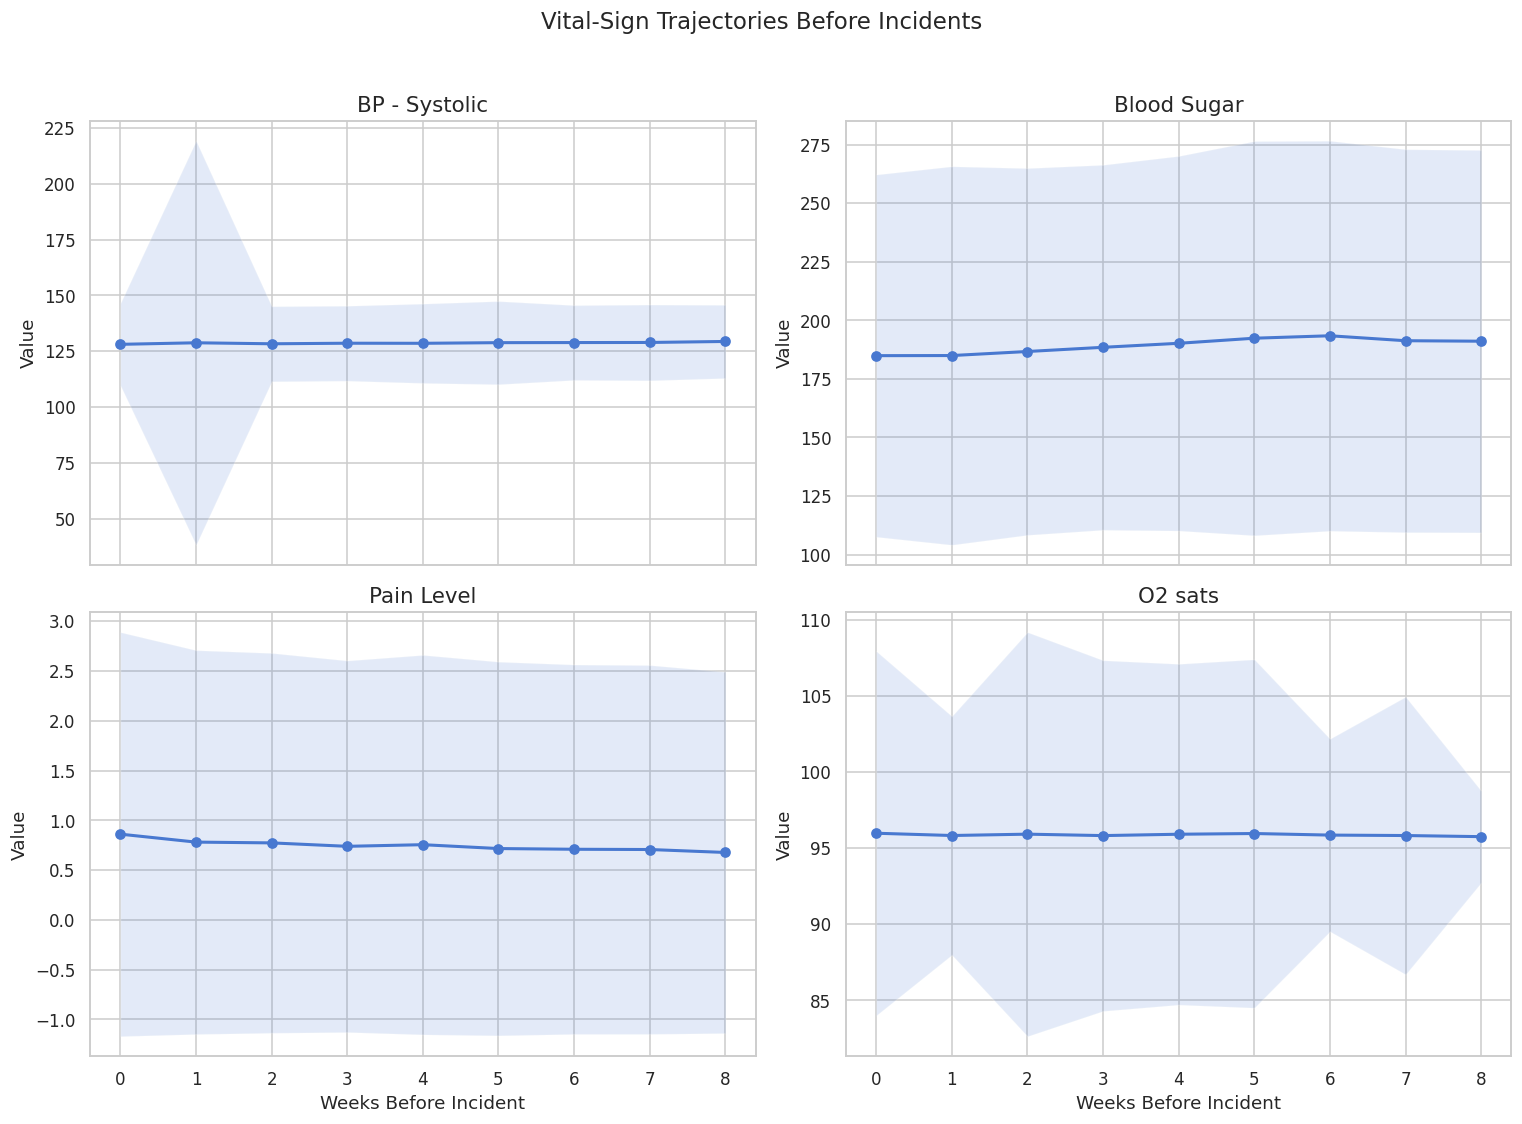

In [11]:
## Chart 7 — Vital-Sign Trajectories Before Incidents

vital_types = ["BP - Systolic", "Blood Sugar", "Pain Level", "O2 sats"]
vitals_sub = vitals[vitals["vital_type"].isin(vital_types) & ~vitals["strikeout"]]

vitals_inc = vitals_sub.merge(inc_dates, on="resident_id")
vitals_inc["days_before"] = (vitals_inc["occurred_at"] - vitals_inc["measured_at"]).dt.days
vitals_inc = vitals_inc[(vitals_inc["days_before"] >= 0) & (vitals_inc["days_before"] <= 56)]
vitals_inc["week_before"] = vitals_inc["days_before"] // 7

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
for ax, vt in zip(axes.flat, vital_types):
    stats = (vitals_inc[vitals_inc["vital_type"] == vt]
             .groupby("week_before")["value"].agg(["mean", "std"]))
    ax.plot(stats.index, stats["mean"], marker="o", lw=2)
    ax.fill_between(stats.index,
                    stats["mean"] - stats["std"],
                    stats["mean"] + stats["std"], alpha=0.15)
    ax.set_title(vt)
    ax.set_ylabel("Value")
    ax.invert_xaxis()
for ax in axes[1]:
    ax.set_xlabel("Weeks Before Incident")
plt.suptitle("Vital-Sign Trajectories Before Incidents",
             fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### Chart 8 — Medication Missed / Late Rate by Incident Status

/tmp/ipykernel_82419/222005878.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=med_agg, x="had_incident", y="missed_late_rate",
/tmp/ipykernel_82419/222005878.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No Incident", "Had Incident"])


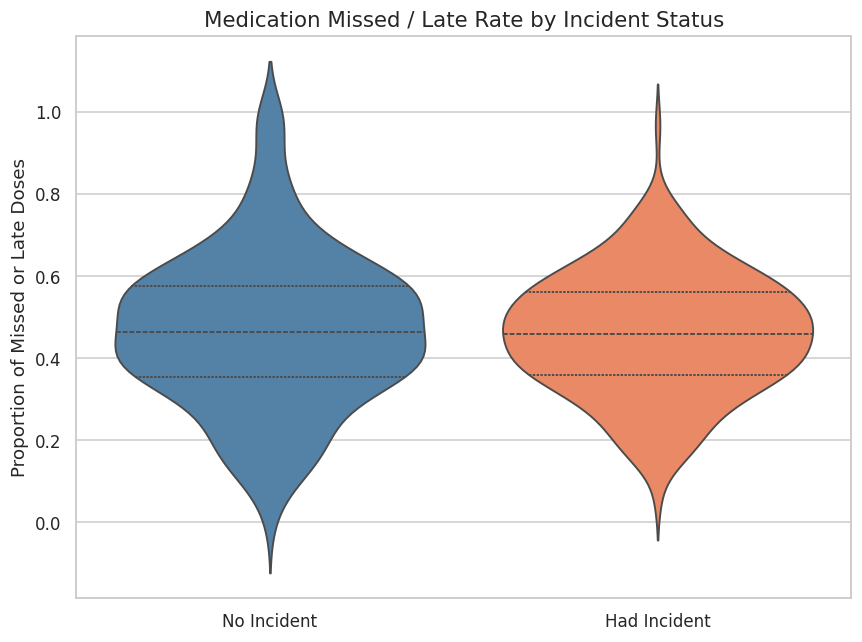

In [12]:
## Chart 8 — Medication Missed / Late Rate by Incident Status

med_agg = (medications.groupby("resident_id")["status"]
           .apply(lambda s: s.isin(["Missed", "Late"]).mean())
           .reset_index(name="missed_late_rate"))
med_agg["had_incident"] = med_agg["resident_id"].isin(incident_residents)

fig, ax = plt.subplots(figsize=(8, 6))
sns.violinplot(data=med_agg, x="had_incident", y="missed_late_rate",
               palette=["steelblue", "coral"], inner="quartile", ax=ax)
ax.set_xticklabels(["No Incident", "Had Incident"])
ax.set_title("Medication Missed / Late Rate by Incident Status")
ax.set_xlabel("")
ax.set_ylabel("Proportion of Missed or Late Doses")
plt.tight_layout()
plt.show()

### Chart 9 — Active Diagnoses at Time of Incident

/tmp/ipykernel_82419/2907414741.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=diag_per_inc, x="incident_type", y="n_diag",


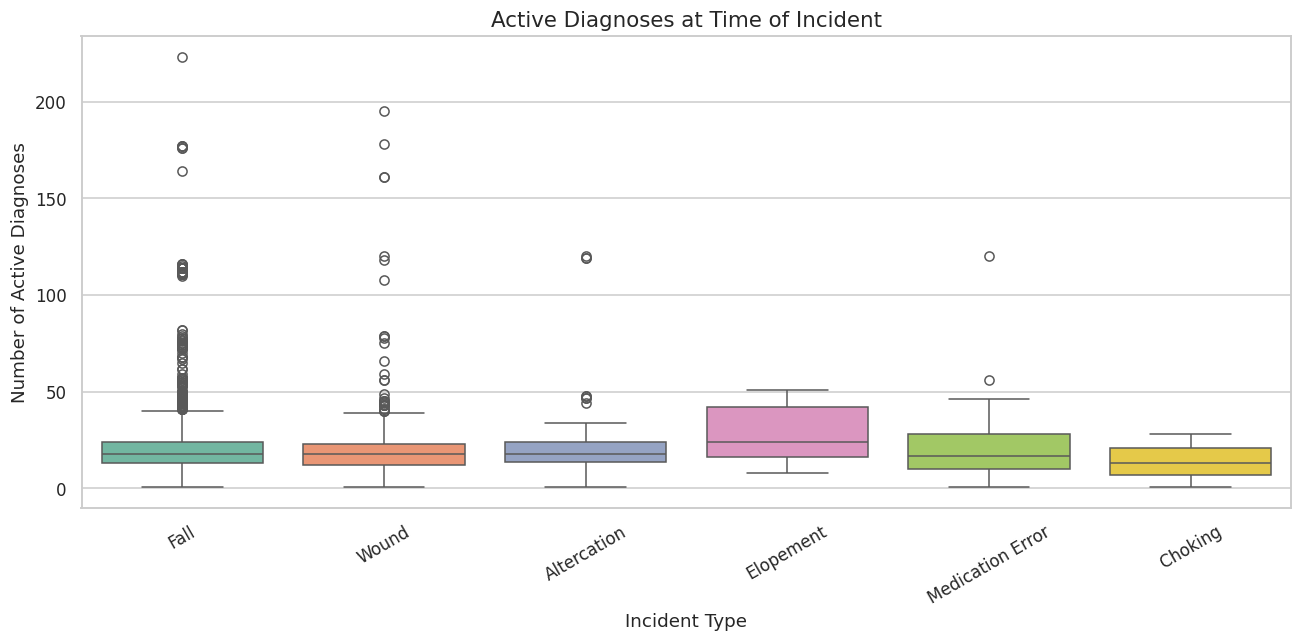

In [13]:
## Chart 9 — Active Diagnoses at Time of Incident

diag_active = diagnoses[~diagnoses["strikeout"]].copy()

inc_diag = inc_valid[["incident_id", "resident_id", "occurred_at", "incident_type"]].merge(
    diag_active[["resident_id", "onset_at", "resolved_at"]],
    on="resident_id", how="left",
)
active_mask = (
    (inc_diag["onset_at"].isna() | (inc_diag["onset_at"] <= inc_diag["occurred_at"]))
    & (inc_diag["resolved_at"].isna() | (inc_diag["resolved_at"] > inc_diag["occurred_at"]))
)
diag_per_inc = (
    inc_diag[active_mask]
    .groupby(["incident_id", "incident_type"])
    .size()
    .reset_index(name="n_diag")
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=diag_per_inc, x="incident_type", y="n_diag",
            palette="Set2", ax=ax)
ax.set_title("Active Diagnoses at Time of Incident")
ax.set_xlabel("Incident Type")
ax.set_ylabel("Number of Active Diagnoses")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

### Chart 10 — Diagnosis Chapter Prevalence by Incident Type (Heatmap)

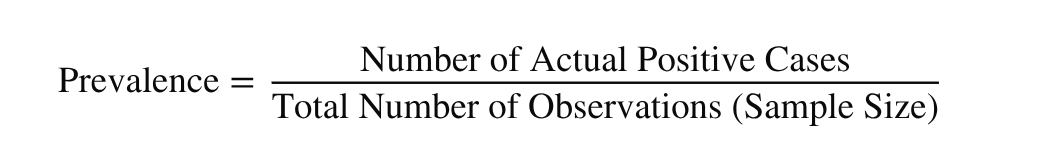


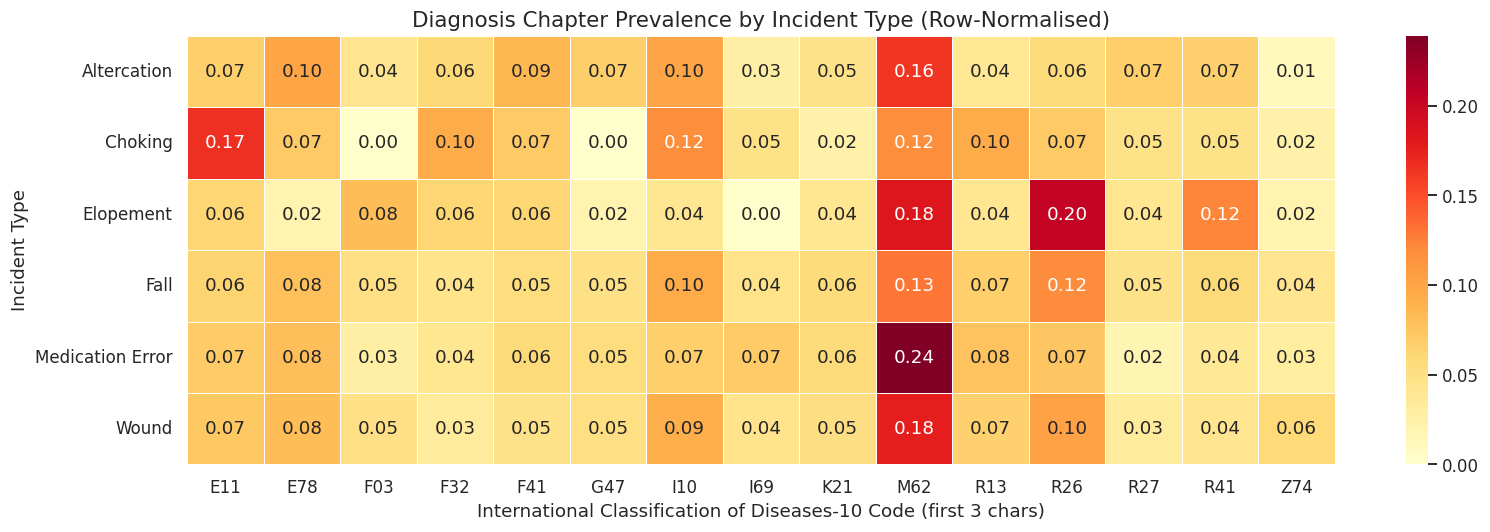

In [14]:
## Chart 10 — Diagnosis Chapter Prevalence by Incident Type (Heatmap)

inc_diag_full = inc_valid[["incident_id", "resident_id", "occurred_at", "incident_type"]].merge(
    diag_active[["resident_id", "icd_10_code", "onset_at", "resolved_at"]]
        .dropna(subset=["icd_10_code"]),
    on="resident_id",
)
mask_active = (
    (inc_diag_full["onset_at"].isna() | (inc_diag_full["onset_at"] <= inc_diag_full["occurred_at"]))
    & (inc_diag_full["resolved_at"].isna() | (inc_diag_full["resolved_at"] > inc_diag_full["occurred_at"]))
)
idf = inc_diag_full[mask_active].copy()
idf["icd3"] = idf["icd_10_code"].str[:3]

top_icd3 = idf["icd3"].value_counts().head(15).index
co = (idf[idf["icd3"].isin(top_icd3)]
      .groupby(["incident_type", "icd3"]).size().unstack(fill_value=0))
co_norm = co.div(co.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(co_norm, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5, ax=ax)
ax.set_title("Diagnosis Chapter Prevalence by Incident Type (Row-Normalised)")
ax.set_xlabel("International Classification of Diseases-10 Code (first 3 chars)")
ax.set_ylabel("Incident Type")
plt.tight_layout()
plt.show()

### Charts 11 & 12 — Prior Incidents and Time Between Consecutive Incidents

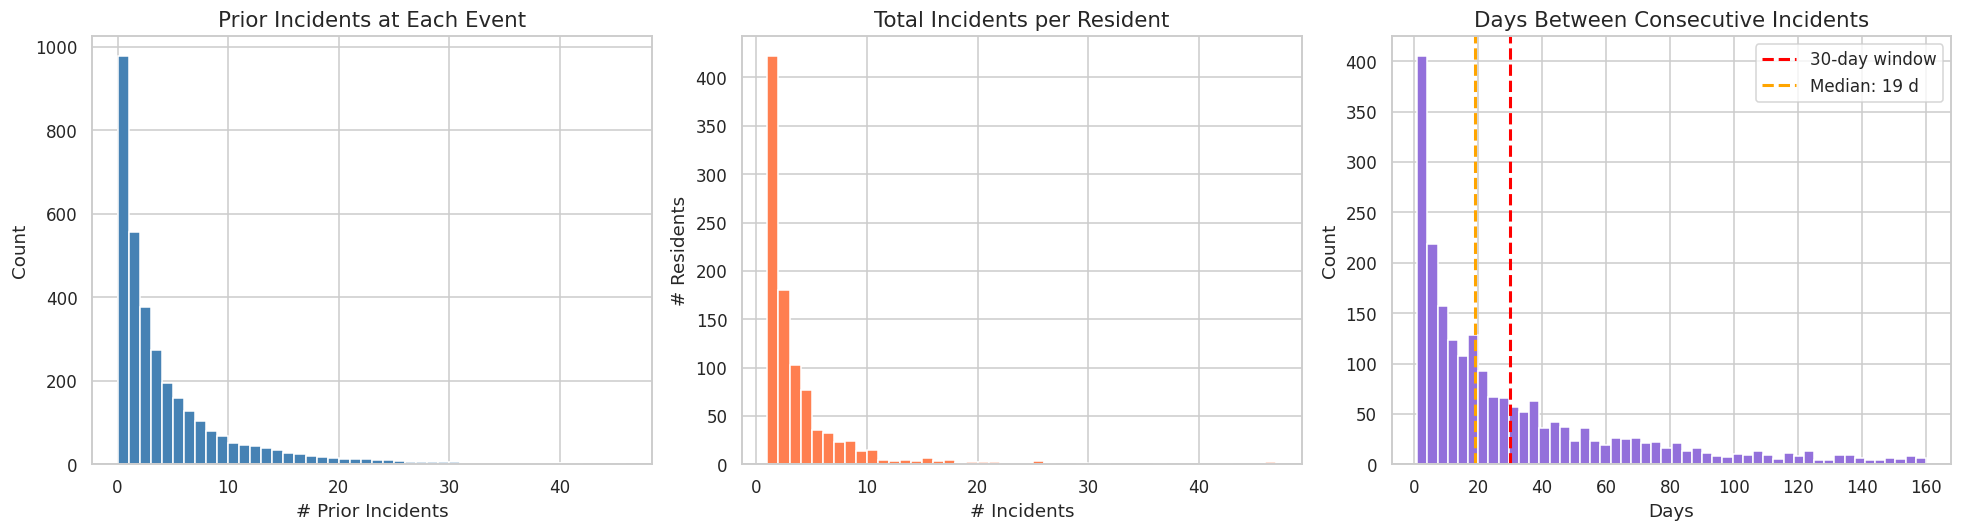

In [15]:
## Charts 11 & 12 — Prior Incidents and Time Between Consecutive Incidents

inc_sorted = inc_valid.sort_values(["resident_id", "occurred_at"])
inc_sorted["prior_count"] = inc_sorted.groupby("resident_id").cumcount()
inc_sorted["prev_time"] = inc_sorted.groupby("resident_id")["occurred_at"].shift(1)
inc_sorted["gap_days"] = (inc_sorted["occurred_at"] - inc_sorted["prev_time"]).dt.days

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(inc_sorted["prior_count"],
             bins=range(0, int(inc_sorted["prior_count"].max()) + 2),
             color="steelblue", edgecolor="white")
axes[0].set_title("Prior Incidents at Each Event")
axes[0].set_xlabel("# Prior Incidents")
axes[0].set_ylabel("Count")

res_total = inc_valid.groupby("resident_id").size()
axes[1].hist(res_total, bins=range(1, int(res_total.max()) + 2),
             color="coral", edgecolor="white")
axes[1].set_title("Total Incidents per Resident")
axes[1].set_xlabel("# Incidents")
axes[1].set_ylabel("# Residents")

gap = inc_sorted["gap_days"].dropna()
gap = gap[gap > 0]
cap = gap.quantile(0.95)
axes[2].hist(gap[gap <= cap], bins=50, color="mediumpurple", edgecolor="white")
axes[2].axvline(30, color="red", ls="--", lw=2, label="30-day window")
axes[2].axvline(gap.median(), color="orange", ls="--", lw=2,
                label=f"Median: {gap.median():.0f} d")
axes[2].set_title("Days Between Consecutive Incidents")
axes[2].set_xlabel("Days")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.tight_layout()
plt.show()

### Chart 13 — Missing Data Across All Tables

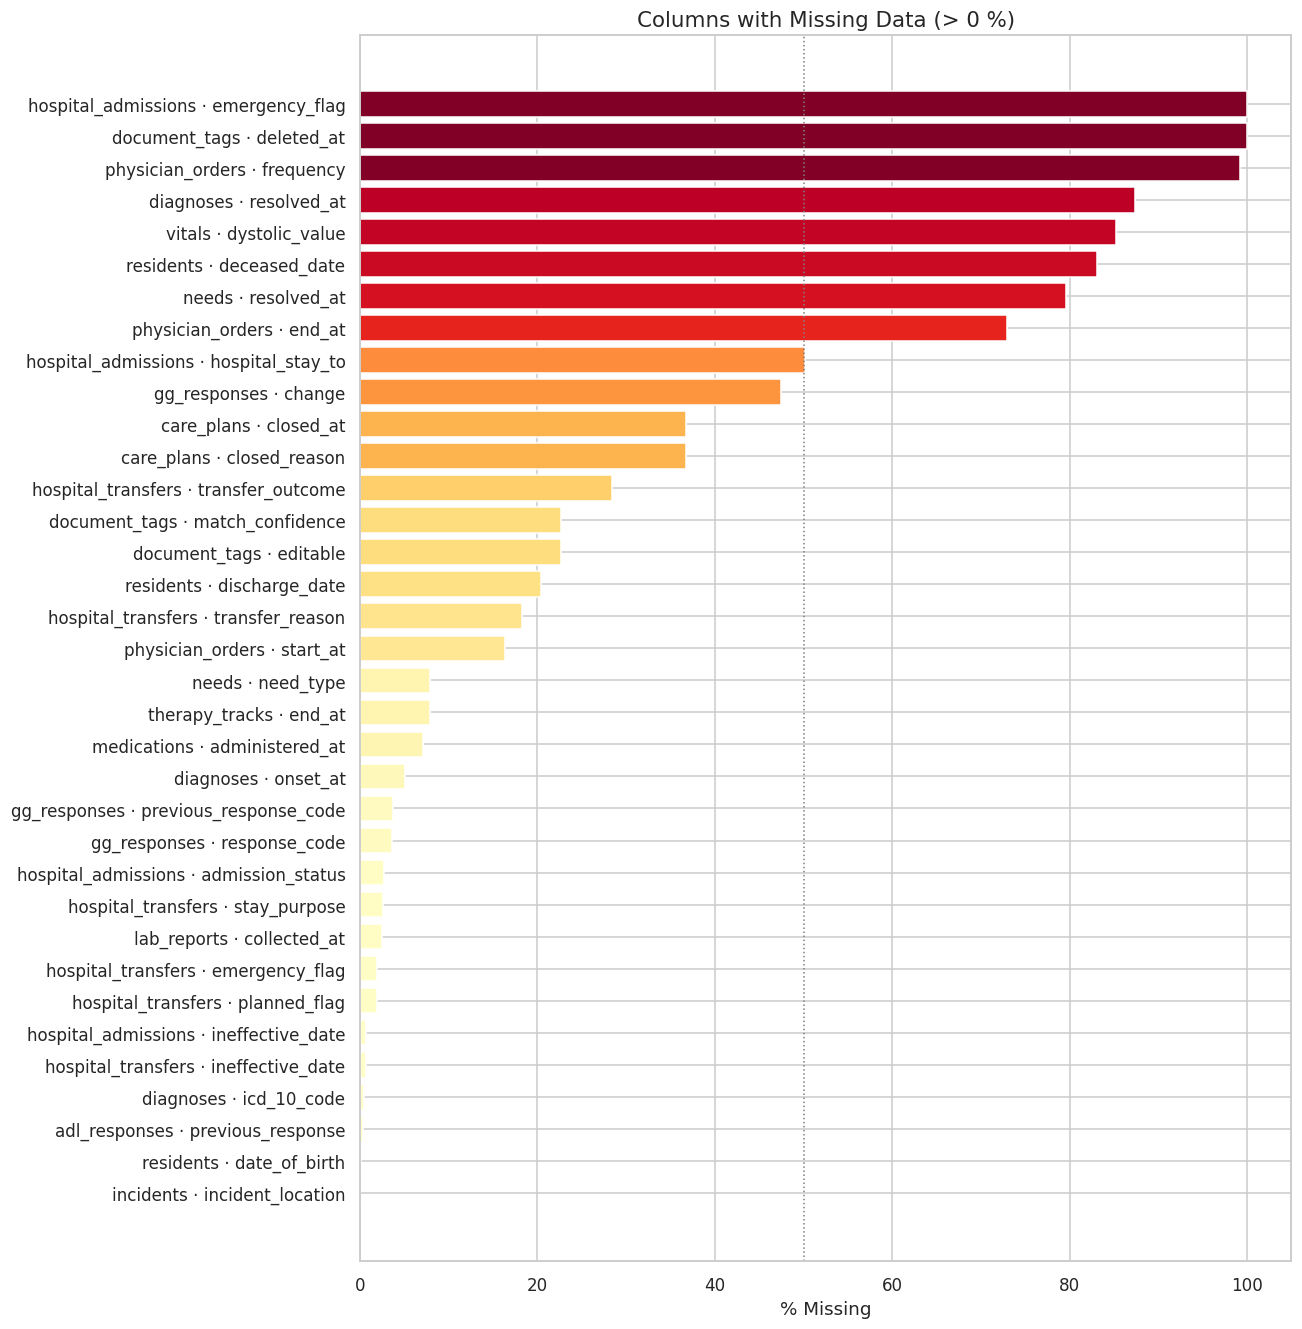

In [16]:
## Chart 13 — Missing Data Across All Tables

records = []
for name, df in dfs.items():
    for col in df.columns:
        pct = df[col].isnull().mean() * 100
        if pct > 0:
            records.append({"table": name, "column": col, "pct": pct})

miss = pd.DataFrame(records).sort_values("pct", ascending=True)
miss["label"] = miss["table"] + " · " + miss["column"]

fig, ax = plt.subplots(figsize=(12, max(6, len(miss) * 0.35)))
colors = plt.cm.YlOrRd(miss["pct"].values / 100)
ax.barh(miss["label"], miss["pct"], color=colors, edgecolor="white")
ax.set_xlabel("% Missing")
ax.set_title("Columns with Missing Data (> 0 %)")
ax.axvline(50, color="gray", ls=":", lw=1)
plt.tight_layout()
plt.show()

### Chart 14 — ADL / GG Response Code Distributions

Activities of Daily Living

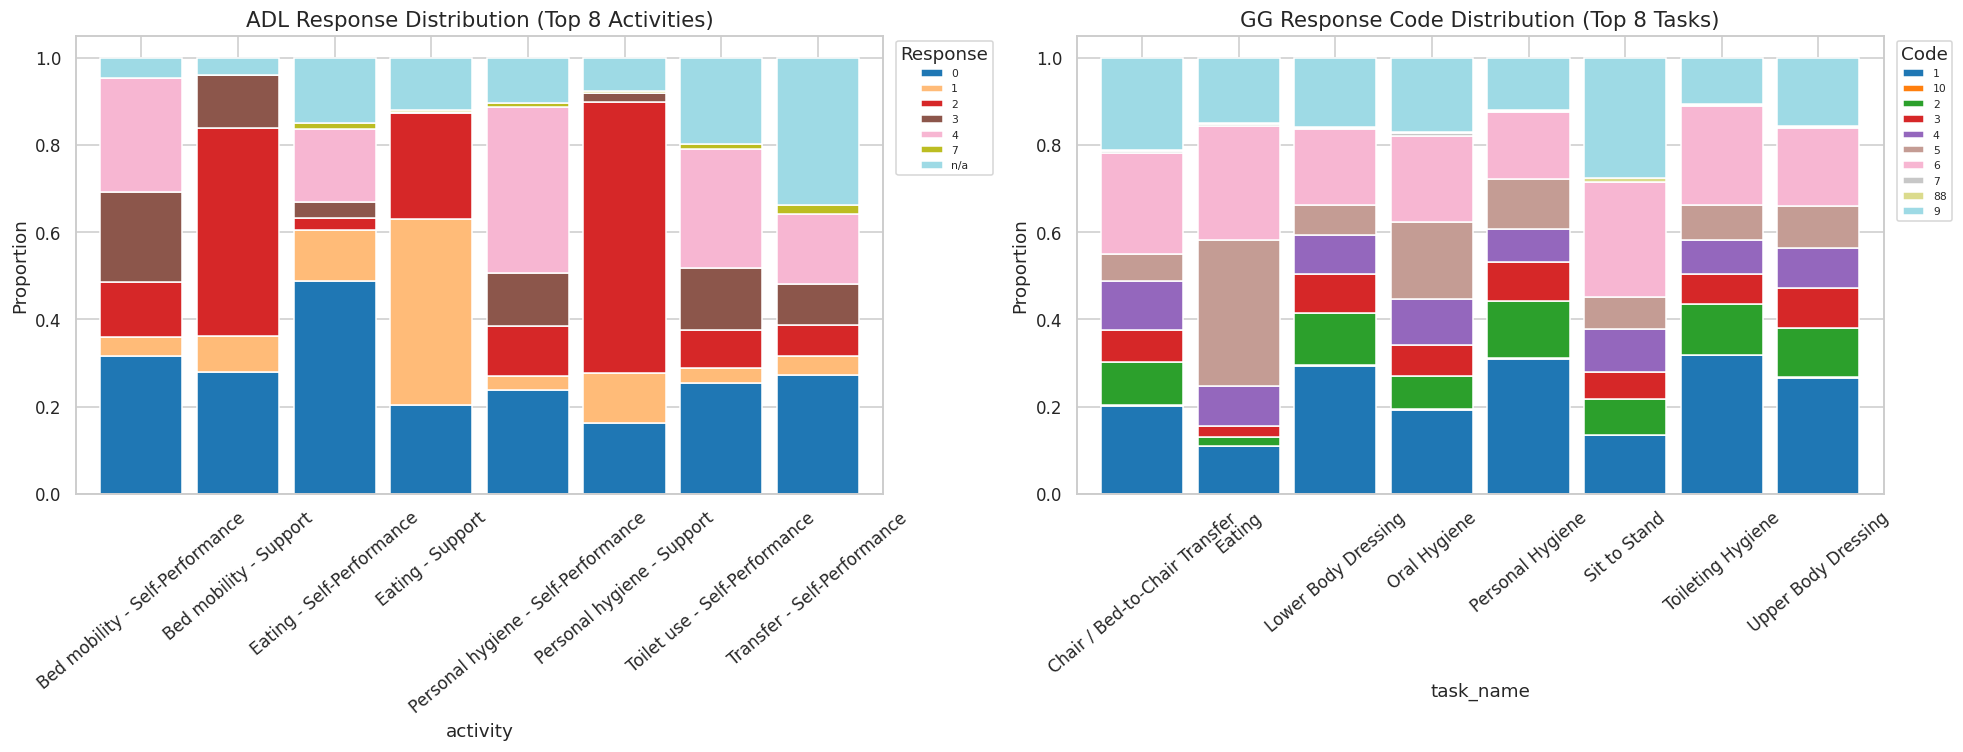

In [17]:
## Chart 14 — ADL / GG Response Code Distributions

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

top_adl_acts = adl["activity"].value_counts().head(8).index
adl_sub = adl[adl["activity"].isin(top_adl_acts)]
ct_adl = pd.crosstab(adl_sub["activity"], adl_sub["response"], normalize="index")
ct_adl.plot.bar(stacked=True, ax=axes[0], colormap="tab20", width=0.85)
axes[0].set_title("ADL Response Distribution (Top 8 Activities)")
axes[0].set_ylabel("Proportion")
axes[0].tick_params(axis="x", rotation=40)
axes[0].legend(title="Response", bbox_to_anchor=(1.01, 1), fontsize=7, ncol=1)

top_gg_tasks = gg["task_name"].value_counts().head(8).index
gg_sub = gg[gg["task_name"].isin(top_gg_tasks)].copy()
gg_sub["code_str"] = gg_sub["response_code"].fillna(-1).astype(int).astype(str)
ct_gg = pd.crosstab(gg_sub["task_name"], gg_sub["code_str"], normalize="index")
ct_gg.plot.bar(stacked=True, ax=axes[1], colormap="tab20", width=0.85)
axes[1].set_title("GG Response Code Distribution (Top 8 Tasks)")
axes[1].set_ylabel("Proportion")
axes[1].tick_params(axis="x", rotation=40)
axes[1].legend(title="Code", bbox_to_anchor=(1.01, 1), fontsize=7, ncol=1)

plt.tight_layout()
plt.show()

### Chart 15 — Feature Correlation Matrix (Resident-Level)

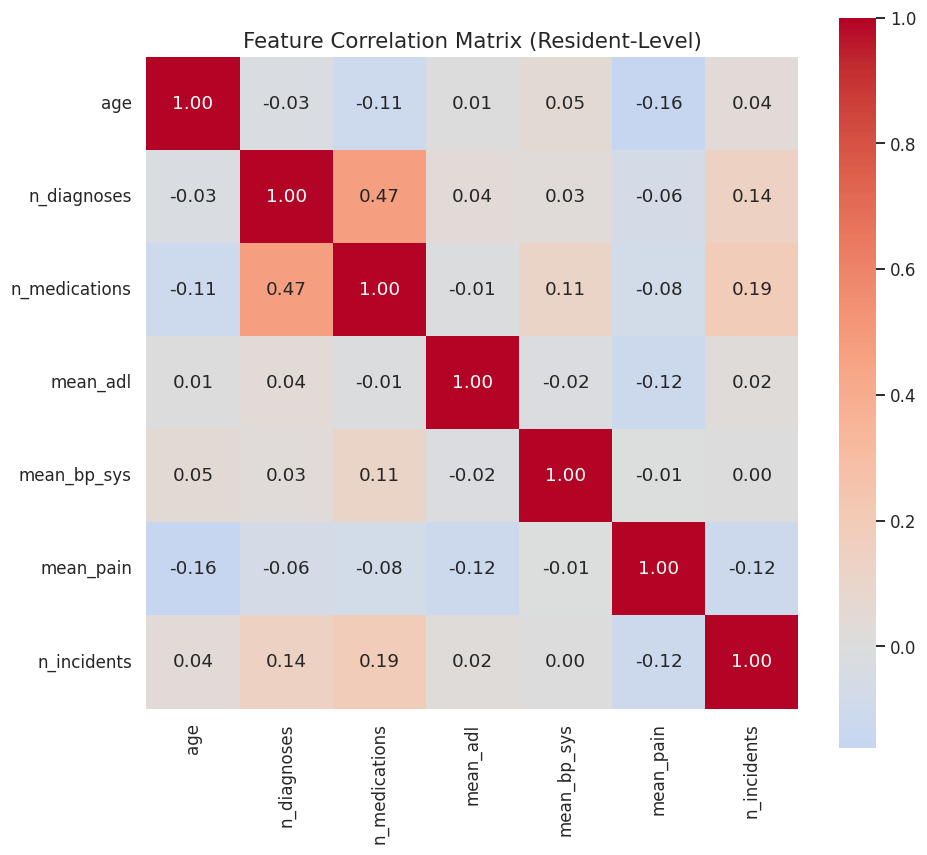

In [18]:
## Chart 15 — Feature Correlation Matrix (Resident-Level)

ref = inc_valid["occurred_at"].max()
rf = residents[["resident_id"]].copy()
rf["age"] = (ref - residents["date_of_birth"]).dt.days / 365.25

diag_n = (diagnoses[~diagnoses["strikeout"]]
          .groupby("resident_id").size().rename("n_diagnoses"))
med_n = medications.groupby("resident_id").size().rename("n_medications")

adl_num = adl[adl["response"].str.match(r"^\d+$", na=False)].copy()
adl_num["val"] = adl_num["response"].astype(int)
adl_avg = adl_num.groupby("resident_id")["val"].mean().rename("mean_adl")

bp_avg = (vitals[vitals["vital_type"] == "BP - Systolic"]
          .groupby("resident_id")["value"].mean().rename("mean_bp_sys"))
pain_avg = (vitals[vitals["vital_type"] == "Pain Level"]
            .groupby("resident_id")["value"].mean().rename("mean_pain"))

inc_n = inc_valid.groupby("resident_id").size().rename("n_incidents")

rf = (rf.join(diag_n, on="resident_id")
        .join(med_n, on="resident_id")
        .join(adl_avg, on="resident_id")
        .join(bp_avg, on="resident_id")
        .join(pain_avg, on="resident_id")
        .join(inc_n, on="resident_id"))
rf["n_incidents"] = rf["n_incidents"].fillna(0)

feat_cols = ["age", "n_diagnoses", "n_medications", "mean_adl",
             "mean_bp_sys", "mean_pain", "n_incidents"]
corr = rf[feat_cols].corr()

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, ax=ax)
ax.set_title("Feature Correlation Matrix (Resident-Level)")
plt.tight_layout()
plt.show()

### Chart 16 — Incident Rate per Facility

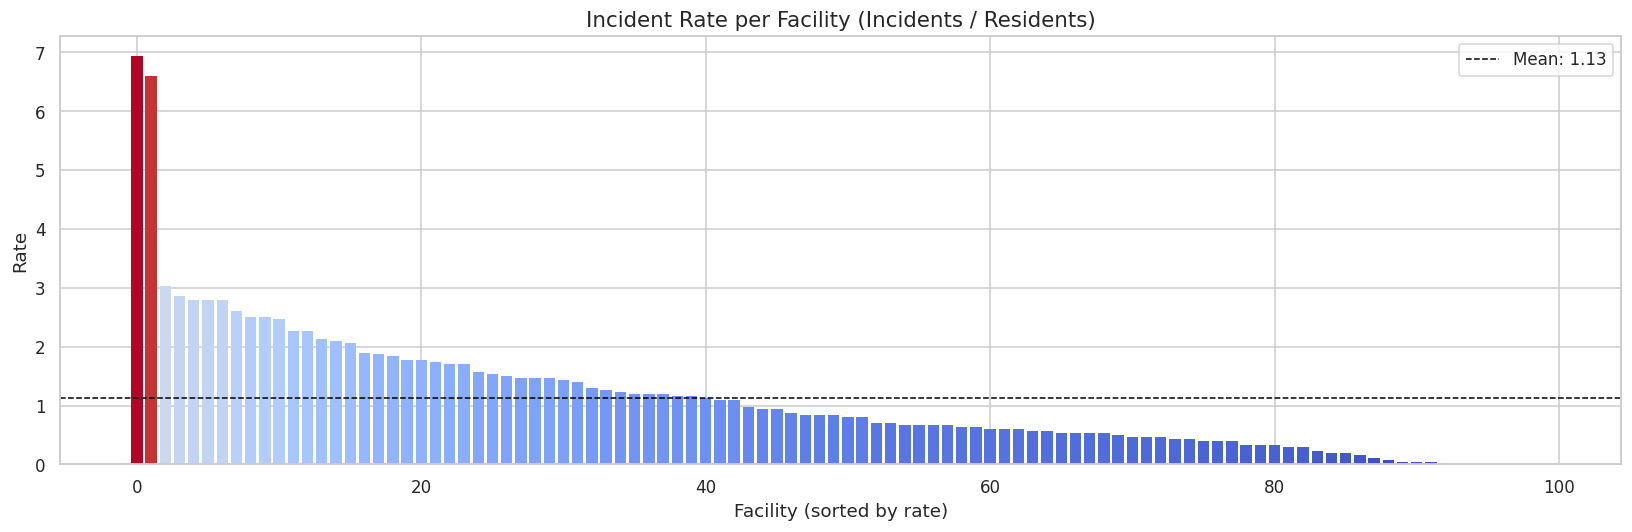

In [19]:
## Chart 16 — Incident Rate per Facility

fac_res = residents.groupby("facility_id").size().rename("n_residents")
fac_inc = inc_valid.groupby("facility_id").size().rename("n_incidents")
fac = pd.concat([fac_res, fac_inc], axis=1).fillna(0)
fac["rate"] = fac["n_incidents"] / fac["n_residents"]
fac = fac.sort_values("rate", ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(15, 5))
colors = plt.cm.coolwarm(fac["rate"].values / fac["rate"].max())
ax.bar(range(len(fac)), fac["rate"], color=colors, edgecolor="none")
mean_rate = fac["rate"].mean()
ax.axhline(mean_rate, color="black", ls="--", lw=1,
           label=f"Mean: {mean_rate:.2f}")
ax.set_title("Incident Rate per Facility (Incidents / Residents)")
ax.set_xlabel("Facility (sorted by rate)")
ax.set_ylabel("Rate")
ax.legend()
plt.tight_layout()
plt.show()

### Chart 17 — Incidents by Day of Week and Hour of Day

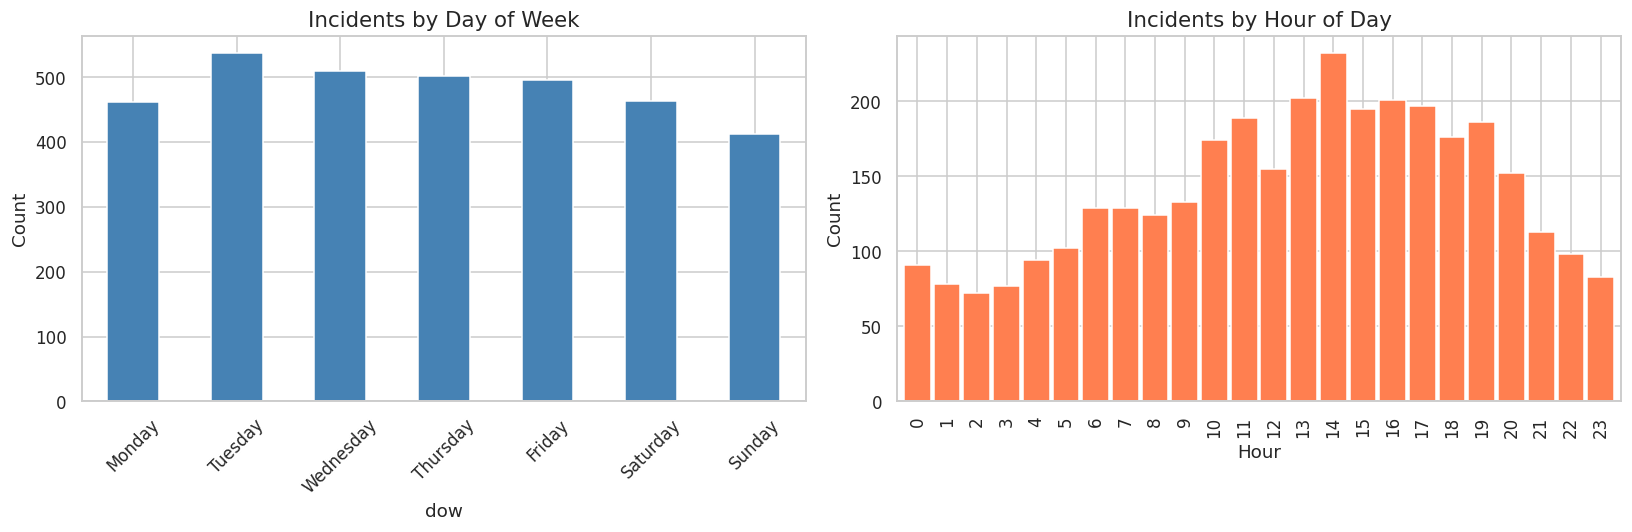

In [20]:
## Chart 17 — Incidents by Day of Week and Hour of Day

inc_dt = inc_valid.copy()
inc_dt["dow"] = inc_dt["occurred_at"].dt.day_name()
inc_dt["hour"] = inc_dt["occurred_at"].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
             "Friday", "Saturday", "Sunday"]
inc_dt["dow"].value_counts().reindex(dow_order).plot.bar(
    ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Incidents by Day of Week")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

inc_dt["hour"].value_counts().sort_index().plot.bar(
    ax=axes[1], color="coral", edgecolor="white", width=0.9)
axes[1].set_title("Incidents by Hour of Day")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

### Chart 18 — Incident → Injury Type & Hospital Transfer Rate

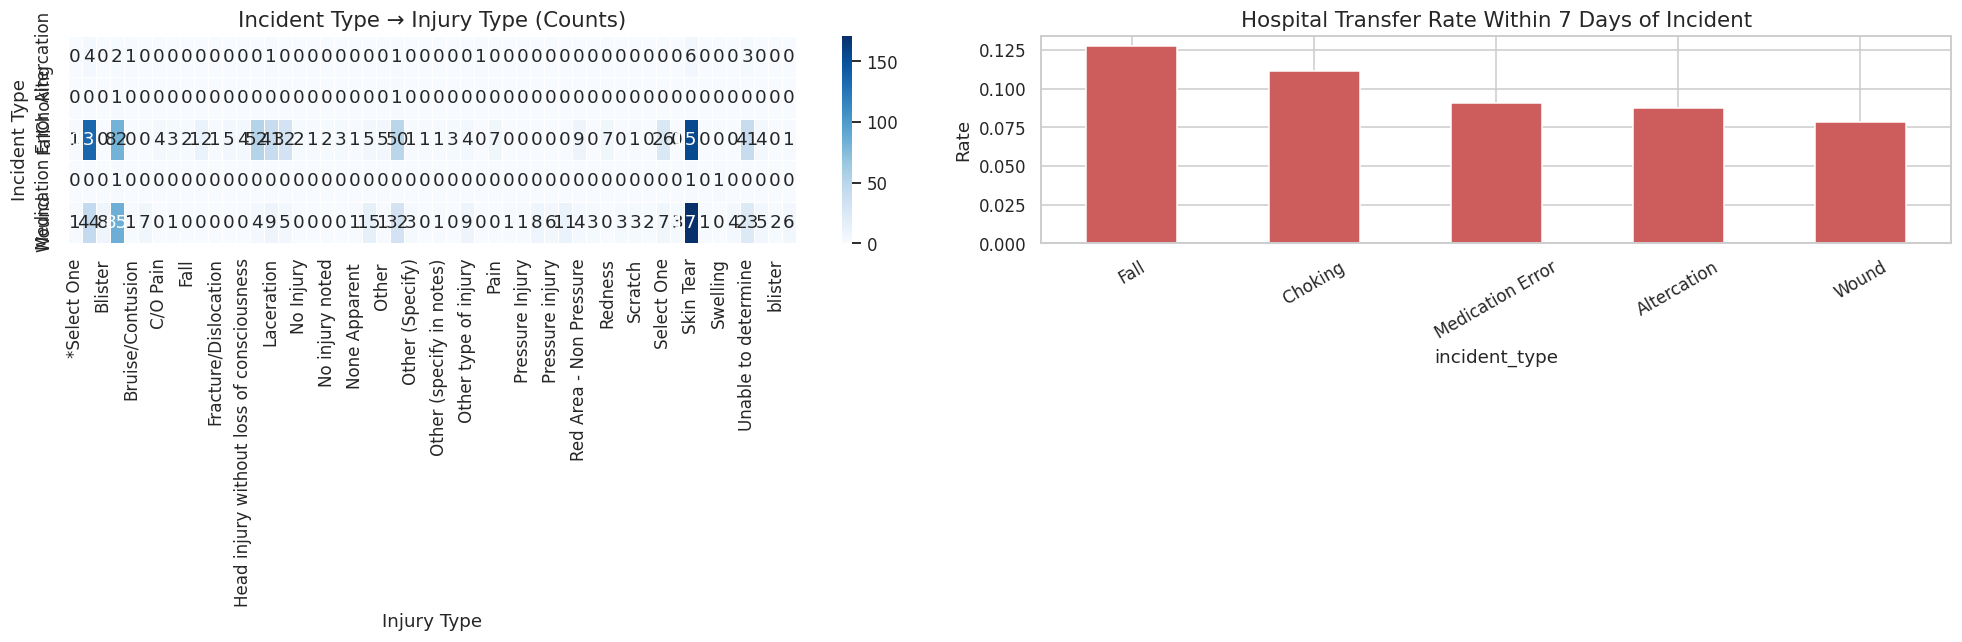

In [21]:
## Chart 18 — Incident → Injury Type & Hospital Transfer Rate

inc_inj = inc_valid.merge(injuries, on="incident_id", how="inner",
                          suffixes=("", "_inj"))
cross = pd.crosstab(inc_inj["incident_type"], inc_inj["injury_type"])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(cross, annot=True, fmt="d", cmap="Blues",
            linewidths=0.5, ax=axes[0])
axes[0].set_title("Incident Type → Injury Type (Counts)")
axes[0].set_xlabel("Injury Type")
axes[0].set_ylabel("Incident Type")

inc_hosp = inc_valid.merge(
    hospital_transfers[["resident_id", "effective_date"]],
    on="resident_id")
inc_hosp["gap"] = (inc_hosp["effective_date"] - inc_hosp["occurred_at"]).dt.days
within_7d = inc_hosp[(inc_hosp["gap"] >= 0) & (inc_hosp["gap"] <= 7)]
transfer_rate = (within_7d.groupby("incident_type").size()
                 / inc_valid["incident_type"].value_counts())
transfer_rate = transfer_rate.dropna().sort_values(ascending=False)

transfer_rate.plot.bar(ax=axes[1], color="indianred", edgecolor="white")
axes[1].set_title("Hospital Transfer Rate Within 7 Days of Incident")
axes[1].set_ylabel("Rate")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### Chart 19 — CDF: Days from Admission to Incident (Prediction Window Analysis)

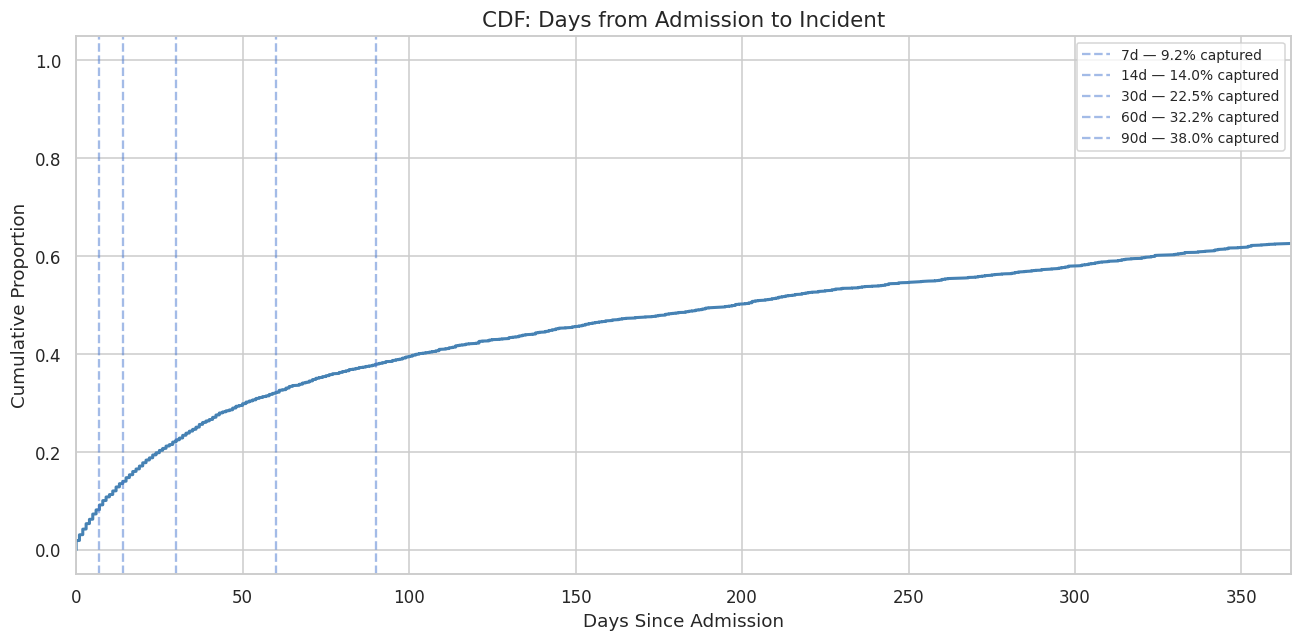

In [22]:
## Chart 19 — CDF: Days from Admission to Incident (Prediction Window Analysis)

inc_adm2 = inc_valid.merge(
    residents[["resident_id", "admission_date"]], on="resident_id")
inc_adm2["days"] = (inc_adm2["occurred_at"] - inc_adm2["admission_date"]).dt.days
valid_d = inc_adm2.loc[inc_adm2["days"] >= 0, "days"].sort_values()

cdf = np.arange(1, len(valid_d) + 1) / len(valid_d)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(valid_d.values, cdf, lw=2, color="steelblue")
for w in [7, 14, 30, 60, 90]:
    pct = (valid_d <= w).mean() * 100
    ax.axvline(w, ls="--", alpha=0.5, label=f"{w}d — {pct:.1f}% captured")
ax.set_title("CDF: Days from Admission to Incident")
ax.set_xlabel("Days Since Admission")
ax.set_ylabel("Cumulative Proportion")
ax.set_xlim(0, 365)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()